# Investigate criticality of anycast prefixes

## how?
* using Savvas' prefix-top-list (PAM'26 paper)

## TODOs
* get more details on these top lists
* do we need to look at DNS toplists (tranco/radar) ourselves?
* what about the top-as-list?

In [118]:
import pandas as pd
from pathlib import Path

import sys
analysis_dir = Path.cwd().parent
sys.path.append(str(analysis_dir))
from add_ASN import CaidaASLookup
import census_helper
from datetime import datetime

ts = datetime(2026, 2, 3)

import matplotlib.pyplot as plt

# configure matplotlib variables (font and size)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


## load in criticality datasets

In [152]:
top_prefix = pd.read_csv('prefix_top_list_ranked.csv.gz')
top_prefix

,prefix,weight,domains,ips,ases
0,2a00:1450:400e::/48,5.820223e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","2a00:1450:400e:10::7, 2a00:1450:400e:10::8, 2a...",15169
1,142.250.179.0/24,2.332626e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","142.250.179.110, 142.250.179.115, 142.250.179....",15169
2,57.144.222.0/23,1.927785e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","57.144.222.1, 57.144.222.128, 57.144.222.129, ...",32934
3,2a03:2880:f36f::/48,1.920212e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","2a03:2880:f36f:120:face:b00c:0:167, 2a03:2880:...",32934
4,2a02:26f0:1180::/48,1.789608e-02,"0.ecom.attccc.com, 0.samsung-internet.filter-l...","2a02:26f0:1180:180::1018, 2a02:26f0:1180:180::...",20940
...,...,...,...,...,...
134654,2402:9400::/32,6.061169e-11,site24x7.enduserexp.com,2402:9400:400:2::204,55803
134655,2403:7000:8000::/34,6.061169e-11,site24x7.enduserexp.com,2403:7000:8000:700::83,45179
134656,173.249.152.0/24,6.061169e-11,site24x7.enduserexp.com,173.249.152.22,36444
134657,179.49.5.0/24,6.061169e-11,site24x7.enduserexp.com,179.49.5.66,22724


In [153]:
top_prefix['weight'].sum()

np.float64(1.0003455557775551)

## load in anycast prefixes

In [120]:
census_v4 = census_helper.download_date(ts, 'v4')
# filter on GCD-confirmed (high-confidence)
census_v4 = census_v4[census_v4['GCD_ICMPv4'] > 1]
# filter on relevant columns
census_v4 = census_v4[['prefix', 'backing_prefix', 'GCD_ICMPv4', 'locations']]

census_v4.head()

,prefix,backing_prefix,GCD_ICMPv4,locations
0,1.0.0.0/24,1.0.0.0/24,75,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
1,1.1.1.0/24,1.1.1.0/24,74,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
3,1.10.10.0/24,1.10.10.0/24,3,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'..."
4,1.12.0.0/24,1.12.0.0/20,5,"[{'city': 'Baltimore', 'country_code': 'US', '..."
5,1.12.12.0/24,1.12.0.0/20,3,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."


In [121]:
print(f"Number of GCD-confirmed /24s {len(census_v4):,}")
print(f"number of backing anycast prefixes {census_v4['backing_prefix'].nunique():,}")

Number of GCD-confirmed /24s 14,332
number of backing anycast prefixes 5,148


## Join datasets

In [154]:
# census_critical = pd.merge(
#     top_prefix,
#     census_v4[['backing_prefix']],
#     left_on='prefix',
#     right_on='backing_prefix',
#     how='left',
# )

top_prefix['is_anycast'] = top_prefix['prefix'].isin(census_v4['backing_prefix'])
census_critical = top_prefix.copy()

# census_critical['is_anycast'] = census_critical['backing_prefix'].notna()
# # drop backing_prefix
# census_critical.drop('backing_prefix', axis=1, inplace=True)

census_critical.head()

,prefix,weight,domains,ips,ases,is_anycast
0,2a00:1450:400e::/48,0.058202,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","2a00:1450:400e:10::7, 2a00:1450:400e:10::8, 2a...",15169,False
1,142.250.179.0/24,0.023326,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","142.250.179.110, 142.250.179.115, 142.250.179....",15169,False
2,57.144.222.0/23,0.019278,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","57.144.222.1, 57.144.222.128, 57.144.222.129, ...",32934,False
3,2a03:2880:f36f::/48,0.019202,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","2a03:2880:f36f:120:face:b00c:0:167, 2a03:2880:...",32934,False
4,2a02:26f0:1180::/48,0.017896,"0.ecom.attccc.com, 0.samsung-internet.filter-l...","2a02:26f0:1180:180::1018, 2a02:26f0:1180:180::...",20940,False


In [155]:
census_critical['ases'].nunique()

28224

In [156]:
# print(f"Number of critical GCD-confirmed /24s {len(census_critical):,}")
print(f"number of critical backing anycast prefixes {census_critical[census_critical['is_anycast']]['prefix'].nunique():,}")

number of critical backing anycast prefixes 2,472


In [157]:
ipv4 = top_prefix[top_prefix['prefix'].str.contains(r'\.')]
ipv6 = top_prefix[top_prefix['prefix'].str.contains(r':')]

print(f"number of critical backing prefixes {top_prefix['prefix'].nunique():,}")
print(f"number of critical backing IPv4 prefixes {ipv4['prefix'].nunique():,}")
print(f"number of critical backing IPv6 prefixes {ipv6['prefix'].nunique():,}")


number of critical backing prefixes 134,659
number of critical backing IPv4 prefixes 121,320
number of critical backing IPv6 prefixes 13,339


## IPv6

In [214]:
census_v6 = census_helper.download_date(ts.year, ts.month, ts.day, 'v6')
# filter on GCD-confirmed (high-confidence)
census_v6 = census_v6[census_v6['GCD_ICMPv6'] > 1]
# filter on relevant columns
census_v6 = census_v6[['prefix', 'backing_prefix', 'GCD_ICMPv6', 'locations', 'ASN']]

census_v6.head()

,prefix,backing_prefix,GCD_ICMPv6,locations,ASN
0,2001:1201:10::/48,2001:1201:10::/48,2,"[{'city': 'Chicago', 'country_code': 'US', 'id...",27661
1,2001:1201::/48,2001:1201::/48,3,"[{'city': 'Monterrey', 'country_code': 'MX', '...",28498
9,2001:12f8:2::/48,2001:12f8:2::/48,3,"[{'city': 'Singapore', 'country_code': 'SG', '...",12136
10,2001:12f8:4::/48,2001:12f8:4::/48,5,"[{'city': None, 'country_code': None, 'id': 'N...",11644
11,2001:12f8:8::/48,2001:12f8:8::/48,3,"[{'city': 'Riga', 'country_code': 'LV', 'id': ...",10906


In [215]:
census_v6['ASN'].nunique()

526

In [128]:
print(f"Number of GCD-confirmed /48s {len(census_v6):,}")
print(f"number of backing anycast prefixes {census_v6['backing_prefix'].nunique():,}")

Number of GCD-confirmed /48s 12,977
number of backing anycast prefixes 2,793


In [158]:
# census_critical = pd.merge(
#     top_prefix,
#     census_v4[['backing_prefix']],
#     left_on='prefix',
#     right_on='backing_prefix',
#     how='left',
# )

census_critical['is_anycast'] = (census_critical['is_anycast'] | census_critical['prefix'].isin(census_v6['backing_prefix']))

# census_critical['is_anycast'] = census_critical['backing_prefix'].notna()
# # drop backing_prefix
# census_critical.drop('backing_prefix', axis=1, inplace=True)

census_critical.head()


# census_critical = pd.merge(
#     census_critical,
#     census_v6['backing_prefix'],
#     left_on='prefix',
#     right_on='backing_prefix',
#     how='left',
# )
#
# census_critical['is_anycast'] = (census_critical['is_anycast'] | census_critical['backing_prefix'].notna())
# census_critical.drop('backing_prefix', axis=1, inplace=True)
#
#
# census_critical.head()

,prefix,weight,domains,ips,ases,is_anycast
0,2a00:1450:400e::/48,0.058202,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","2a00:1450:400e:10::7, 2a00:1450:400e:10::8, 2a...",15169,False
1,142.250.179.0/24,0.023326,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","142.250.179.110, 142.250.179.115, 142.250.179....",15169,False
2,57.144.222.0/23,0.019278,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","57.144.222.1, 57.144.222.128, 57.144.222.129, ...",32934,False
3,2a03:2880:f36f::/48,0.019202,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","2a03:2880:f36f:120:face:b00c:0:167, 2a03:2880:...",32934,False
4,2a02:26f0:1180::/48,0.017896,"0.ecom.attccc.com, 0.samsung-internet.filter-l...","2a02:26f0:1180:180::1018, 2a02:26f0:1180:180::...",20940,False


In [159]:
ipv6 = census_critical[census_critical['prefix'].str.contains(r':')]

#print(f"Number of critical GCD-confirmed /48s {len(ipv6):,}")
print(f"number of ipv6 top backing anycast prefixes {ipv6[ipv6['is_anycast']]['prefix'].nunique():,}")

number of ipv6 top backing anycast prefixes 1,005


In [160]:
print(f"number of critical backing anycast prefixes {census_critical[census_critical['is_anycast']]['prefix'].nunique():,}")


number of critical backing anycast prefixes 3,477


In [161]:
census_critical

,prefix,weight,domains,ips,ases,is_anycast
0,2a00:1450:400e::/48,5.820223e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","2a00:1450:400e:10::7, 2a00:1450:400e:10::8, 2a...",15169,False
1,142.250.179.0/24,2.332626e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","142.250.179.110, 142.250.179.115, 142.250.179....",15169,False
2,57.144.222.0/23,1.927785e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","57.144.222.1, 57.144.222.128, 57.144.222.129, ...",32934,False
3,2a03:2880:f36f::/48,1.920212e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","2a03:2880:f36f:120:face:b00c:0:167, 2a03:2880:...",32934,False
4,2a02:26f0:1180::/48,1.789608e-02,"0.ecom.attccc.com, 0.samsung-internet.filter-l...","2a02:26f0:1180:180::1018, 2a02:26f0:1180:180::...",20940,False
...,...,...,...,...,...,...
134654,2402:9400::/32,6.061169e-11,site24x7.enduserexp.com,2402:9400:400:2::204,55803,False
134655,2403:7000:8000::/34,6.061169e-11,site24x7.enduserexp.com,2403:7000:8000:700::83,45179,False
134656,173.249.152.0/24,6.061169e-11,site24x7.enduserexp.com,173.249.152.22,36444,False
134657,179.49.5.0/24,6.061169e-11,site24x7.enduserexp.com,179.49.5.66,22724,False


In [162]:
census_critical['weight'].sum()

np.float64(1.0003455557775551)

In [163]:
census_critical[~census_critical['is_anycast']]

,prefix,weight,domains,ips,ases,is_anycast
0,2a00:1450:400e::/48,5.820223e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","2a00:1450:400e:10::7, 2a00:1450:400e:10::8, 2a...",15169,False
1,142.250.179.0/24,2.332626e-02,"0-ai--zenmele-pages-dev-0.cdn.ampproject.org, ...","142.250.179.110, 142.250.179.115, 142.250.179....",15169,False
2,57.144.222.0/23,1.927785e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","57.144.222.1, 57.144.222.128, 57.144.222.129, ...",32934,False
3,2a03:2880:f36f::/48,1.920212e-02,"0.facebook.com, 0.freebasics.com, 5-edge-chat....","2a03:2880:f36f:120:face:b00c:0:167, 2a03:2880:...",32934,False
4,2a02:26f0:1180::/48,1.789608e-02,"0.ecom.attccc.com, 0.samsung-internet.filter-l...","2a02:26f0:1180:180::1018, 2a02:26f0:1180:180::...",20940,False
...,...,...,...,...,...,...
134654,2402:9400::/32,6.061169e-11,site24x7.enduserexp.com,2402:9400:400:2::204,55803,False
134655,2403:7000:8000::/34,6.061169e-11,site24x7.enduserexp.com,2403:7000:8000:700::83,45179,False
134656,173.249.152.0/24,6.061169e-11,site24x7.enduserexp.com,173.249.152.22,36444,False
134657,179.49.5.0/24,6.061169e-11,site24x7.enduserexp.com,179.49.5.66,22724,False


In [164]:
census_critical[census_critical['is_anycast']]


,prefix,weight,domains,ips,ases,is_anycast
5,2603:1000::/25,1.722019e-02,-keyid-5a351244819ff6a2ea3218508f957382901614b...,"2603:1000:104:1::280, 2603:1000:104:1::281, 26...",8075,True
6,2606:4700::/44,1.664669e-02,"0.as.slashdot.org, 0.as.sourceforge.net, 0.goa...","2606:4700:0:6257:b0bd:620f:731:4857, 2606:4700...",13335,True
7,151.101.204.0/22,9.963849e-03,"0.testing.pinterest.com, 01.emailinboundproces...","151.101.204.102, 151.101.204.106, 151.101.204....",54113,True
9,2606:4700:20::/44,9.118654e-03,"0.19706903.xyz, 0.4863232c.xyz, 0.64786087.xyz...","2606:4700:20::6818:1037, 2606:4700:20::6818:10...",13335,True
10,162.159.128.0/19,8.799750e-03,"01net.it, 02db8c58be312b9a93c947918f83eae8e006...","162.159.128.102, 162.159.128.12, 162.159.128.2...",13335,True
...,...,...,...,...,...,...
134079,216.194.103.0/24,1.289038e-09,metaverifiedsupport.net,216.194.103.228,13150,True
134166,3.163.238.0/24,1.165329e-09,jetpacglobal.com,3.163.238.61,16509,True
134168,204.13.138.0/24,1.156848e-09,factualdata.com,204.13.138.15,35280,True
134303,2606:4700:9ad4::/46,9.828748e-10,ynlhjm.com,2606:4700:9ad6::6f12:5e0e,13335,True


In [177]:
census_critical['weight'].mean()

np.float64(7.428731505339822e-06)

In [178]:
census_critical[census_critical['is_anycast']]['weight'].mean()

np.float64(0.00010278978820496743)

In [179]:
census_critical[~census_critical['is_anycast']]['weight'].mean()


np.float64(4.901171366413709e-06)

In [180]:
census_critical['weight'].median()


np.float64(1.540754576289887e-07)

In [181]:
census_critical[census_critical['is_anycast']]['weight'].median()


np.float64(5.201979629348192e-07)

In [182]:
census_critical[~census_critical['is_anycast']]['weight'].median()


np.float64(1.5074678770073348e-07)

In [165]:
census_critical['weight'].sum()

np.float64(1.0003455557775551)

In [166]:
census_critical.columns

Index(['prefix', 'weight', 'domains', 'ips', 'ases', 'is_anycast'], dtype='object')

In [167]:
#!pip install seaborn
import seaborn as sns

# Assuming df is your dataframe
df = census_critical.copy()

# 1. Sort by weight descending (High rank first)
df = df.sort_values('weight', ascending=False).reset_index(drop=True)

# 2. Create the Cumulative Weight axis (0 to 1)
total_weight = df['weight'].sum()
df['cum_weight'] = df['weight'].cumsum() / total_weight

# Ensure is_anycast is numeric (0 or 1) for calculation
df['is_anycast_int'] = df['is_anycast'].astype(int)

/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_37659/2831945445.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('weight_percentile_bin')['is_anycast_int'].mean().reset_index()


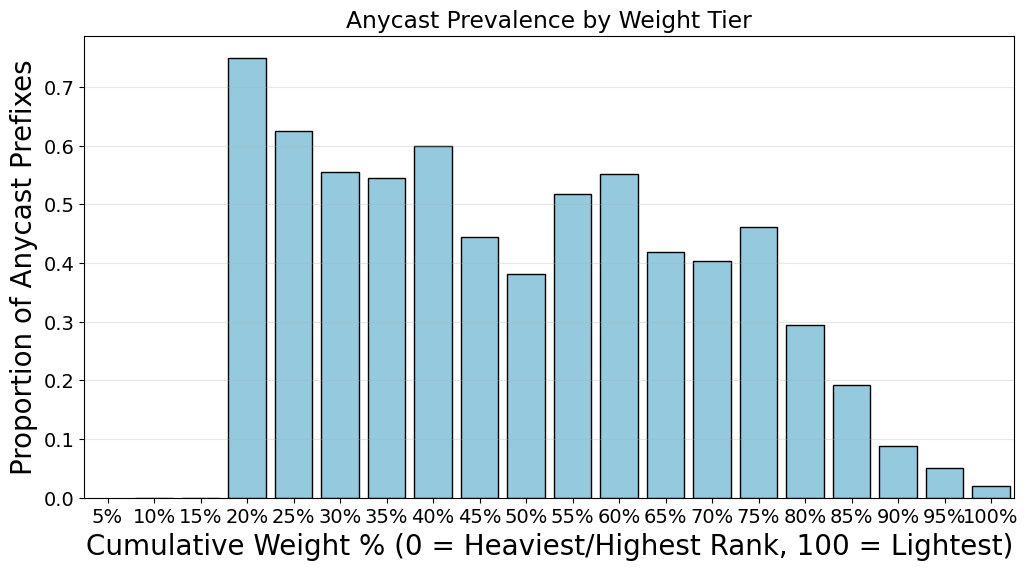

In [168]:
# Create bins for the cumulative weight (0.0 to 1.0)
# 20 bins = 5% weight increments
bins = np.linspace(0, 1, 21)
labels = [f"{int(x*100)}%" for x in bins[1:]]

df['weight_percentile_bin'] = pd.cut(df['cum_weight'], bins=bins, labels=labels)

# Calculate prevalence of Anycast in each bin
# Mean of boolean/int gives the percentage
bin_stats = df.groupby('weight_percentile_bin')['is_anycast_int'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=bin_stats, x='weight_percentile_bin', y='is_anycast_int', color='skyblue', edgecolor='black')

plt.xlabel("Cumulative Weight % (0 = Heaviest/Highest Rank, 100 = Lightest)")
plt.ylabel("Proportion of Anycast Prefixes")
plt.title("Anycast Prevalence by Weight Tier")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [169]:
bin_stats

,weight_percentile_bin,is_anycast_int
0,5%,NaN
1,10%,0.000000
2,15%,0.000000
3,20%,0.750000
4,25%,0.625000
5,30%,0.555556
6,35%,0.545455
7,40%,0.600000
8,45%,0.444444
9,50%,0.380952


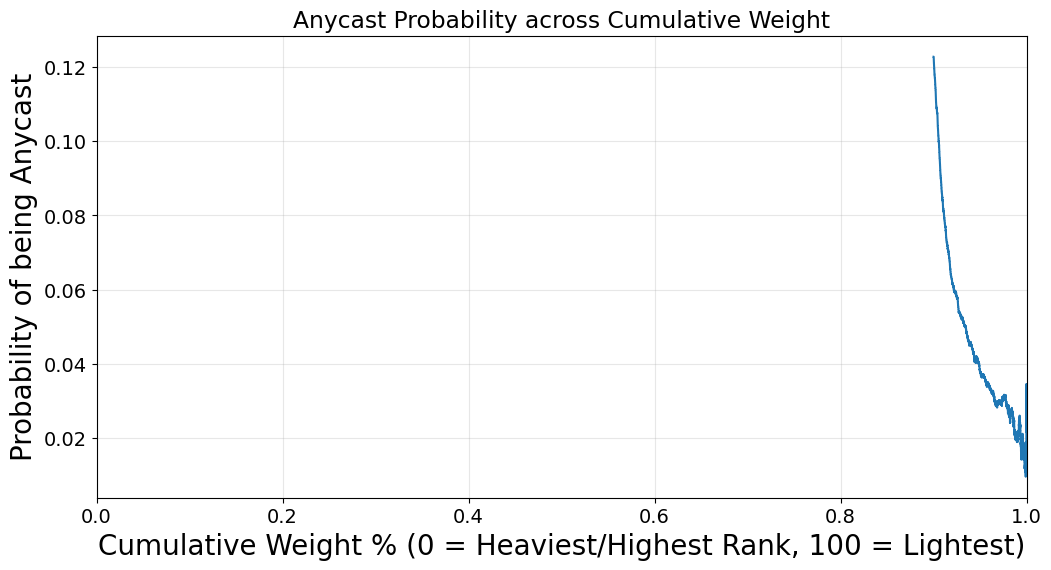

In [170]:
# We use the index as a proxy for 'count of prefixes' within the sorted list
# but plot against cum_weight.

# Rolling window size: Adjust based on your dataset size.
# If you have 10k rows, window=500 is good. If 1M rows, window=10000.
window_size = int(len(df) * 0.05) # 5% of rows smoothing

df['rolling_anycast'] = df['is_anycast_int'].rolling(window=window_size, center=True).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['cum_weight'], df['rolling_anycast'], label='Anycast Probability')

plt.xlabel("Cumulative Weight % (0 = Heaviest/Highest Rank, 100 = Lightest)")
plt.ylabel("Probability of being Anycast")
plt.title("Anycast Probability across Cumulative Weight")
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [172]:
df = df.sort_values('weight', ascending=False).reset_index(drop=True)


In [173]:
df['cum_weight_pct'] = df['weight'].cumsum() * 100


In [174]:
df['anycast_cdf'] = (
    df['is_anycast'].cumsum() / df['is_anycast'].sum()
) * 100

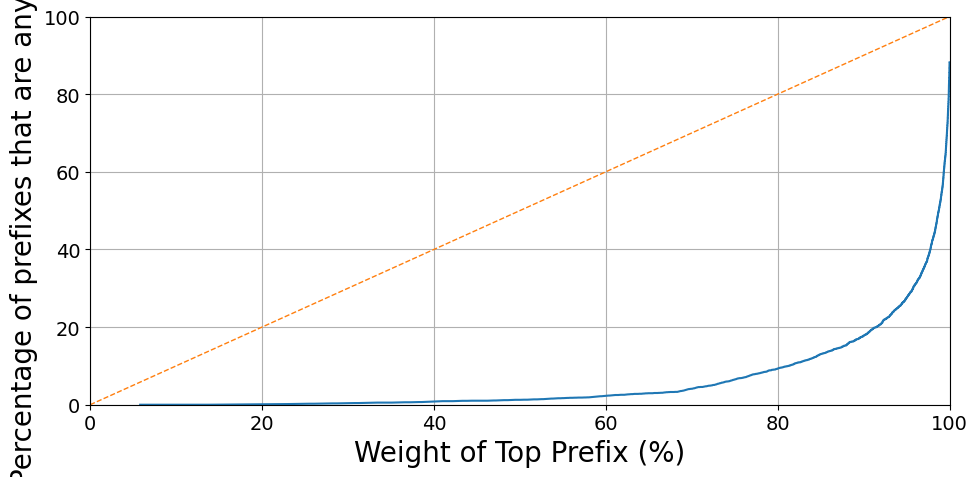

In [176]:
plt.figure(figsize=(10, 5))

plt.plot(
    df['cum_weight_pct'],
    df['anycast_cdf'],
)

plt.xlabel('Weight of Top Prefix (%)')
plt.ylabel('Percentage of prefixes that are anycast')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.plot([0, 100], [0, 100], linestyle='--', linewidth=1)


plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_37659/3605326109.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


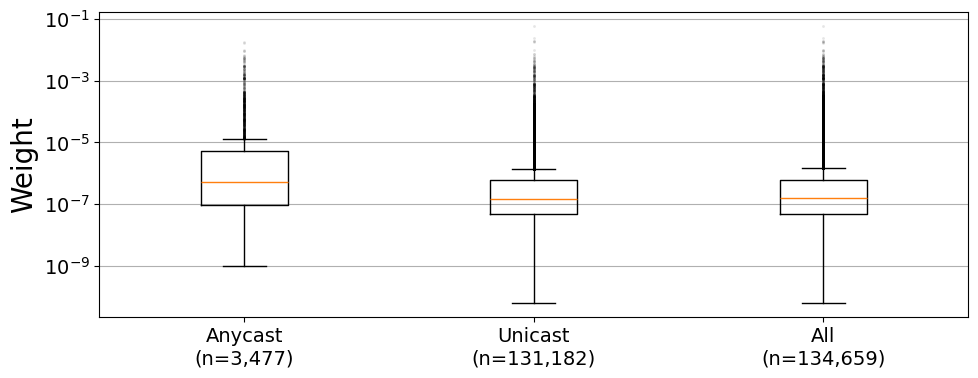

In [221]:
n_unicast = (~df.is_anycast).sum()
n_anycast = df.is_anycast.sum()
n_all = len(df)

plt.figure(figsize=(10, 4))

plt.boxplot(
    [
        df[df.is_anycast]['weight'],
        df[~df.is_anycast]['weight'],
        df['weight'],
    ],
    labels = [
    f'Anycast\n(n={n_anycast:,})',
    f'Unicast\n(n={n_unicast:,})',
    f'All\n(n={n_all:,})'
    ],
    showfliers=True,
        flierprops=dict(
        marker='o',
        markersize=1,
        alpha=0.1
    )
)

plt.grid(True, axis='y')

plt.yscale('log')
plt.ylabel('Weight')
plt.tight_layout()

plt.savefig("top_list_ranking.pdf", format="pdf", bbox_inches='tight')

plt.show()


/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_37659/2740232455.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


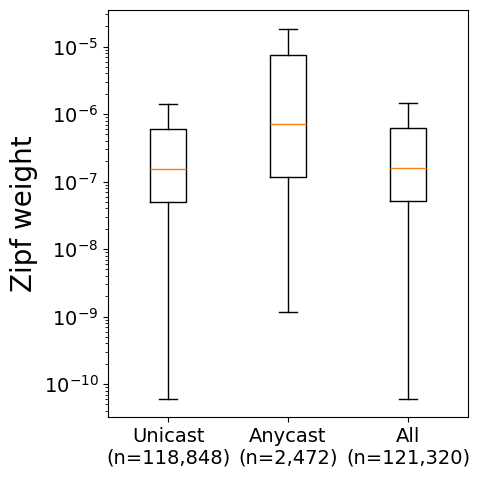

In [194]:
# ipv4-only

ipv4_df = df[~df['prefix'].str.contains(r':')]

n_unicast = (~ipv4_df.is_anycast).sum()
n_anycast = ipv4_df.is_anycast.sum()
n_all = len(ipv4_df)

plt.figure(figsize=(5, 5))

plt.boxplot(
    [
        ipv4_df[~ipv4_df.is_anycast]['weight'],
        ipv4_df[ipv4_df.is_anycast]['weight'],
        ipv4_df['weight'],
    ],
    labels = [
    f'Unicast\n(n={n_unicast:,})',
    f'Anycast\n(n={n_anycast:,})',
    f'All\n(n={n_all:,})'
    ],
    showfliers=False
)

plt.yscale('log')
plt.ylabel('Zipf weight')
plt.tight_layout()
plt.show()


/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_37659/1338605561.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


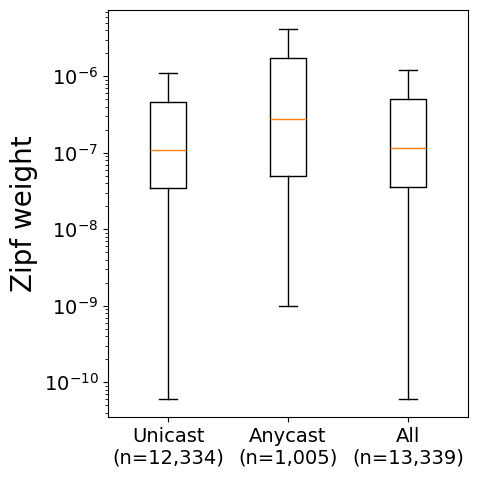

In [195]:
ipv6_df = df[df['prefix'].str.contains(r':')]

n_unicast = (~ipv6_df.is_anycast).sum()
n_anycast = ipv6_df.is_anycast.sum()
n_all = len(ipv6_df)

plt.figure(figsize=(5, 5))

plt.boxplot(
    [
        ipv6_df[~ipv6_df.is_anycast]['weight'],
        ipv6_df[ipv6_df.is_anycast]['weight'],
        ipv6_df['weight'],
    ],
    labels = [
    f'Unicast\n(n={n_unicast:,})',
    f'Anycast\n(n={n_anycast:,})',
    f'All\n(n={n_all:,})'
    ],
    showfliers=False
)

plt.yscale('log')
plt.ylabel('Zipf weight')
plt.tight_layout()
plt.show()